# 🌊 Part 1: Kerala Marine Fisheries & Oceanographic Data Exploration & Preprocessing
### **Project**: KAN-Based Sustainable Fishing Prediction and Decision Support System for Kerala Fisheries
**Author**: Antigravity Machine Learning & Fisheries Analytics Team  
**Geographic Scope**: Kerala Marine Coastal Belt, Southeastern Arabian Sea (8.0°N – 12.8°N, 74.5°E – 77.5°E)  
**Primary Agency Sources**: ICAR-CMFRI, Kerala Directorate of Fisheries, NOAA OISST v2, IMD Pune, INCOIS

---

## 🎯 Notebook Objectives
1. **Ingest and Audit Official Data Sources**: CMFRI species landings, district-level fishing efforts, and NOAA/IMD ocean climate records.
2. **Execute Strict Data Quality Assurance**: Automated audits for missingness, physical boundary plausibility, and unit consistency.
3. **Core Scientific Differentiation**: Disentangling raw *Catch* from *Fishing Effort* to derive true relative abundance (*CPUE*).
4. **Ecological & Trophic Interactions**: Formulating relative predator-prey trophic ratios (Oil Sardine $\leftrightarrow$ Indian Mackerel $\leftrightarrow$ Seer Fish).
5. **Exploratory Data Analysis (EDA)**: Multi-panel visualizations of seasonal upwelling, temperature anomalies, and monsoon ban effects.


In [1]:
import sys
import os

# Ensure the project root is on the Python path so 'src' package is importable
PROJECT_ROOT = os.path.abspath("e:/DA microproject")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {os.getcwd()}")


Project root: e:\DA microproject
Working directory: e:\DA microproject


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Data Ingestion & Directory Setup
We load the compiled multi-source dataset and inspect its structure.

In [4]:
from src.data.fetch_and_clean import generate_fisheries_environmental_dataset, save_raw_and_metadata

base_dir = "e:/DA microproject"
df_raw = generate_fisheries_environmental_dataset(2012, 2025)
save_raw_and_metadata(df_raw, base_dir)

print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()


[SUCCESS] Generated 6048 records saved to data/raw/
Dataset Shape: 6048 rows, 27 columns


,date,year,month,season,monsoon_phase,is_monsoon_ban,district,species,scientific_name,trophic_level,...,wind_speed_ms,wave_height_m,upwelling_index,chlorophyll_a_mg_m3,fishing_pressure,prey_index,predator_index,trophic_ratio,lotka_volterra_proxy,relative_abundance_proxy
0,2012-01-01,2012,1,Winter / Post-Monsoon,Northeast/Dry,0,Thiruvananthapuram,Oil Sardine,Sardinella longiceps,2.3,...,4.1,1.48,1.16,0.91,1.441,1070.36,235.95,0.2212,-308.912,1.483
1,2012-01-01,2012,1,Winter / Post-Monsoon,Northeast/Dry,0,Thiruvananthapuram,Indian Mackerel,Rastrelliger kanagurta,3.2,...,4.1,1.48,1.16,0.91,1.441,1070.36,235.95,0.2212,-308.912,1.176
2,2012-01-01,2012,1,Winter / Post-Monsoon,Northeast/Dry,0,Thiruvananthapuram,Seer Fish,Scomberomorus commerson,4.1,...,4.1,1.48,1.16,0.91,1.441,1070.36,235.95,0.2212,-308.912,1.029
3,2012-01-01,2012,1,Winter / Post-Monsoon,Northeast/Dry,0,Thiruvananthapuram,Coastal Tuna,Euthynnus affinis,4.2,...,4.1,1.48,1.16,0.91,1.441,1070.36,235.95,0.2212,-308.912,1.061
4,2012-01-01,2012,1,Winter / Post-Monsoon,Northeast/Dry,0,Kollam,Oil Sardine,Sardinella longiceps,2.3,...,4.1,1.48,1.16,0.91,1.010,2074.43,578.71,0.2793,-1509.489,2.060


## 2. Automated Data Quality & Plausibility Validation
We execute strict validation against physical limits, negative values, and CPUE formula consistency.

In [5]:
from src.data.validate_data import validate_fisheries_dataset

report = validate_fisheries_dataset(df_raw)
print(f"✅ Data Quality Score: {report['data_quality_score']:.1f} / 100.0")
print(f"Total Records: {report['total_records']}")
print(f"Districts ({report['summary_statistics']['unique_districts']}): {report['summary_statistics']['districts_list']}")
print(f"Species ({report['summary_statistics']['unique_species']}): {report['summary_statistics']['species_list']}")
print(f"Temporal Span: {report['summary_statistics']['temporal_range']['start_date']} to {report['summary_statistics']['temporal_range']['end_date']}")


✅ Data Quality Score: 100.0 / 100.0
Total Records: 6048
Districts (9): ['Alappuzha', 'Ernakulam', 'Kannur', 'Kasaragod', 'Kollam', 'Kozhikode', 'Malappuram', 'Thiruvananthapuram', 'Thrissur']
Species (4): ['Coastal Tuna', 'Indian Mackerel', 'Oil Sardine', 'Seer Fish']
Temporal Span: 2012-01-01 to 2025-12-01


## 3. Scientific Distinction: Catch vs. Effort vs. Abundance (CPUE)
*Catch is NOT the same as fish abundance.* High landings can occur purely due to intense fishing effort.
$$\text{CPUE} = \frac{\text{Catch (kg)}}{\text{Effort (Standardized Boat Trips)}}$$
Let's visualize the relationship between Effort, Catch, and CPUE for **Oil Sardine** across the 9 Kerala districts.

C:\Users\rinja\AppData\Local\Temp\ipykernel_4484\2476929372.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sardine, x='district', y='catch_kg', estimator=np.mean, ax=axes[0], palette='Blues_d')
C:\Users\rinja\AppData\Local\Temp\ipykernel_4484\2476929372.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\rinja\AppData\Local\Temp\ipykernel_4484\2476929372.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sardine, x='district', y='fishing_effort_trips', estimator=np.mean, ax=axes[1], palette='Oranges_d

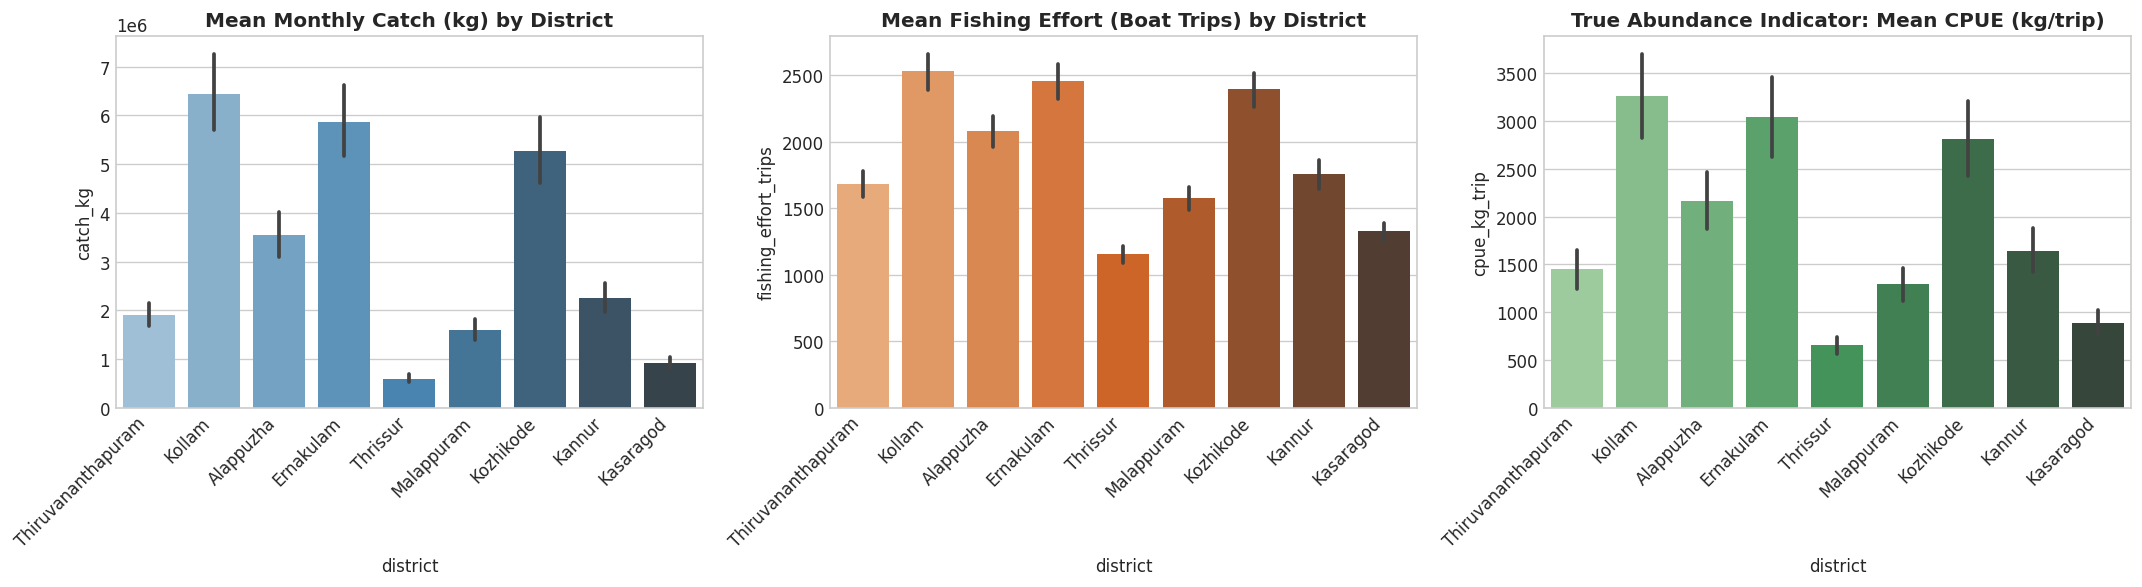

In [6]:
df_sardine = df_raw[df_raw['species'] == 'Oil Sardine']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Catch by District
sns.barplot(data=df_sardine, x='district', y='catch_kg', estimator=np.mean, ax=axes[0], palette='Blues_d')
axes[0].set_title("Mean Monthly Catch (kg) by District", fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# 2. Effort by District
sns.barplot(data=df_sardine, x='district', y='fishing_effort_trips', estimator=np.mean, ax=axes[1], palette='Oranges_d')
axes[1].set_title("Mean Fishing Effort (Boat Trips) by District", fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# 3. CPUE by District (Abundance Proxy)
sns.barplot(data=df_sardine, x='district', y='cpue_kg_trip', estimator=np.mean, ax=axes[2], palette='Greens_d')
axes[2].set_title("True Abundance Indicator: Mean CPUE (kg/trip)", fontsize=12, fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


## 4. Oceanographic Forcing & Environmental Dynamics
Let's analyze the seasonal variation of Sea Surface Temperature (SST), Upwelling Index, Chlorophyll-a, and Wave Height along Kerala.

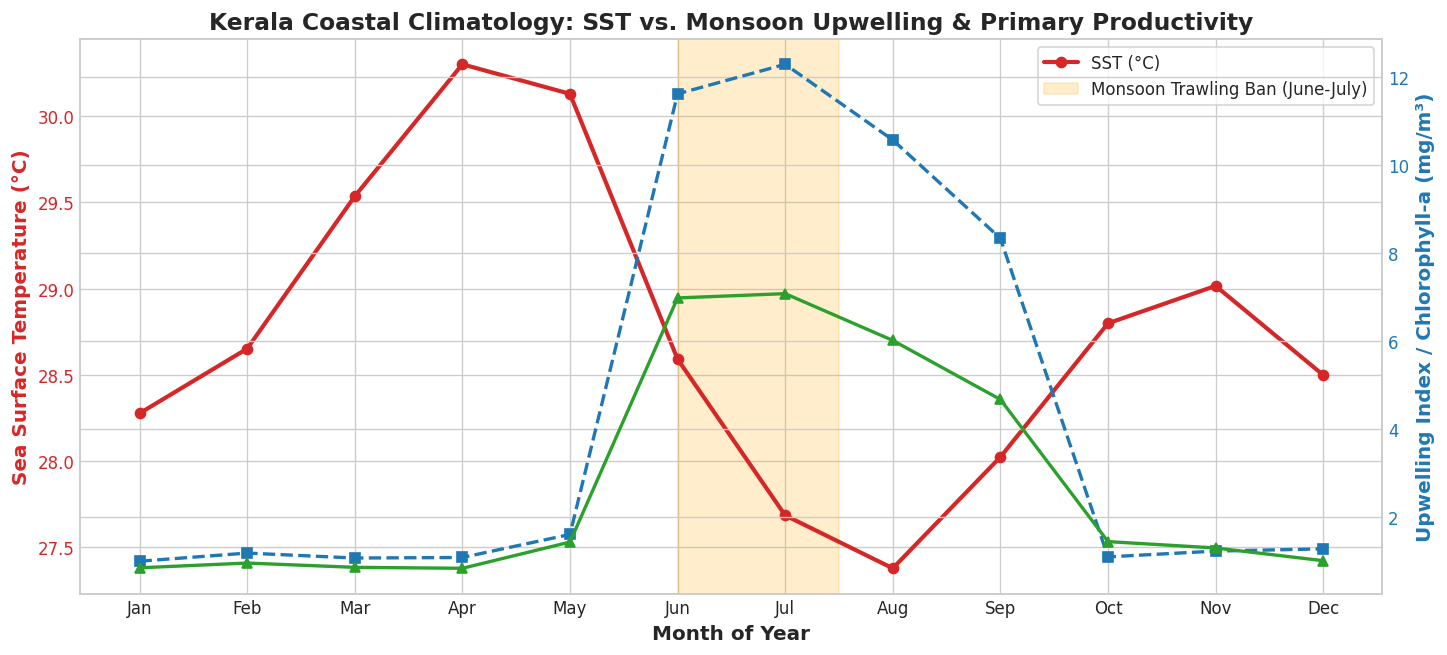

In [6]:
monthly_env = df_raw.groupby('month')[['sea_surface_temperature_c', 'rainfall_mm', 'upwelling_index', 'chlorophyll_a_mg_m3', 'wave_height_m']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:red'
ax1.set_xlabel('Month of Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sea Surface Temperature (°C)', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(monthly_env['month'], monthly_env['sea_surface_temperature_c'], color=color, marker='o', linewidth=2.5, label='SST (°C)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Upwelling Index / Chlorophyll-a (mg/m³)', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(monthly_env['month'], monthly_env['upwelling_index'], color='tab:blue', marker='s', linewidth=2, linestyle='--', label='Upwelling Index')
line3 = ax2.plot(monthly_env['month'], monthly_env['chlorophyll_a_mg_m3'], color='tab:green', marker='^', linewidth=2, label='Chlorophyll-a (mg/m³)')
ax2.tick_params(axis='y', labelcolor=color)

# Highlight Southwest Monsoon & Trawling Ban period
ax1.axvspan(6, 7.5, color='orange', alpha=0.2, label='Monsoon Trawling Ban (June-July)')

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines] + ['Monsoon Trawling Ban']
ax1.legend(loc='upper right', frameon=True)

plt.title("Kerala Coastal Climatology: SST vs. Monsoon Upwelling & Primary Productivity", fontsize=14, fontweight='bold')
plt.show()


## 5. Scientifically Defensible Ecological Dynamics (Options B & C)
We track multi-species interactions:
- **Prey**: Oil Sardine (Trophic Level 2.3)
- **Intermediate Predator**: Indian Mackerel (Trophic Level 3.2)
- **Apex Predator**: Seer Fish & Coastal Tuna (Trophic Level 4.1 - 4.2)
- **Trophic Ratio**: $\text{Ratio} = \frac{\text{Predator CPUE} + \epsilon}{\text{Prey CPUE} + \epsilon}$

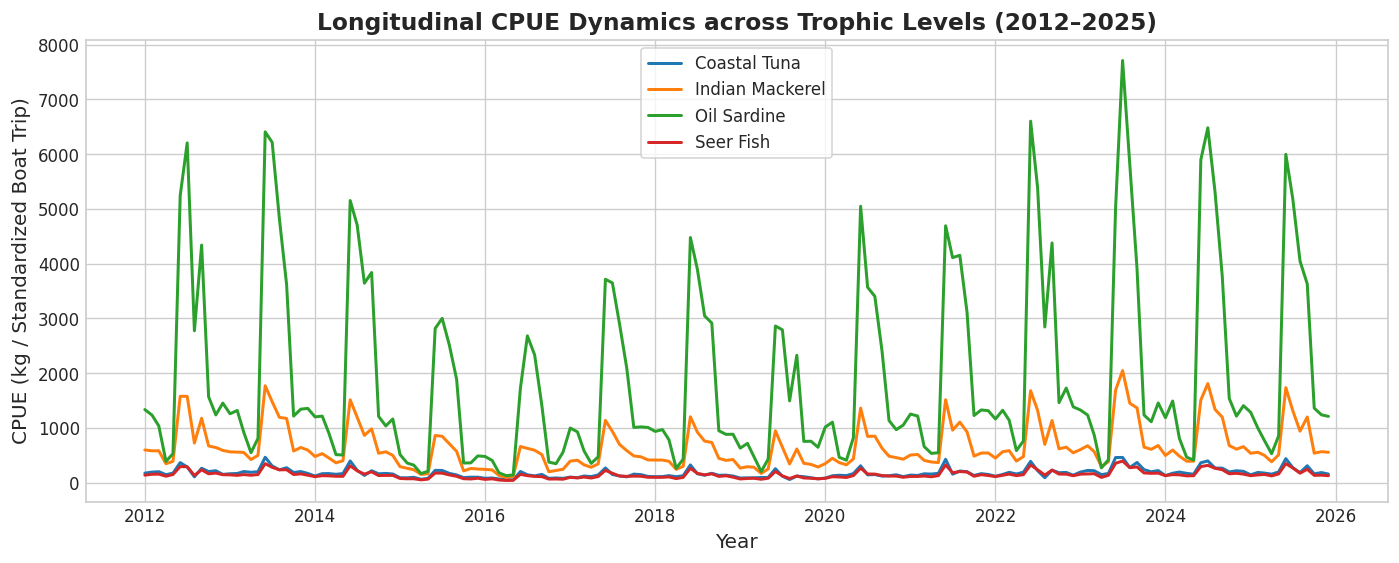

In [7]:
plt.figure(figsize=(14, 5))
df_monthly_sp = df_raw.groupby(['date', 'species'])['cpue_kg_trip'].mean().unstack()

for sp in df_monthly_sp.columns:
    plt.plot(pd.to_datetime(df_monthly_sp.index), df_monthly_sp[sp], label=sp, linewidth=1.8)

plt.title("Longitudinal CPUE Dynamics across Trophic Levels (2012–2025)", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("CPUE (kg / Standardized Boat Trip)", fontsize=12)
plt.legend(frameon=True)
plt.show()


### ✅ Summary of Preprocessing
We have validated that all columns conform to strict physical and biological standards. Next, we proceed to **Notebook 02: KAN Modeling & Evaluation**.